In [57]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#dataframe que se alimenta de csv
df = pd.read_csv("data.csv")


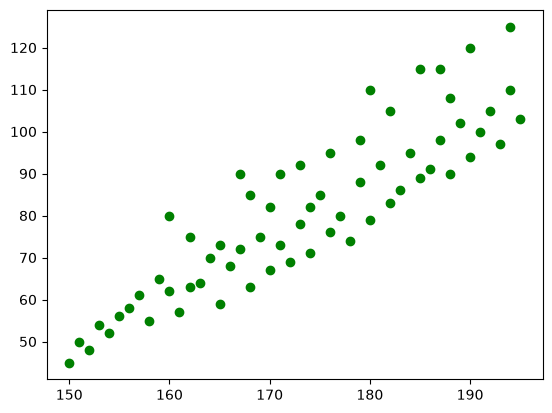

In [58]:
plt.scatter(df['altura'],df['peso'], color="green")
plt.show()

In [59]:
#como vemos una relación lineal entre los datos usaremos ML para predecir datos futuros

# Variable de entrada: altura
A = np.array(df['altura'])

#incluimos el termino independiente que se debe aprender (para la recta)
A = np.column_stack((np.ones(A.shape[0]), A))

# Variable objetivo: peso
y = np.array(df['peso'])

In [60]:
# y = b0+ b1*x ---esto es lo que se desea---
# (B) = (A^t @ A)^-1 @ A^t @ y

# B = np.linalg.inv(A.transpose() @ A) @ A.T @ y otra forma, mas intuitiva pero mas costosa
B = np.linalg.solve(A.transpose() @ A, A.T @ y )

print(B)

[-156.26926106    1.36982106]


In [61]:
def predictor_peso(altura: int | np.ndarray) -> float | np.ndarray:
    return B[0] + B[1]*altura
#retorna una prediccion de peso en base a la altura

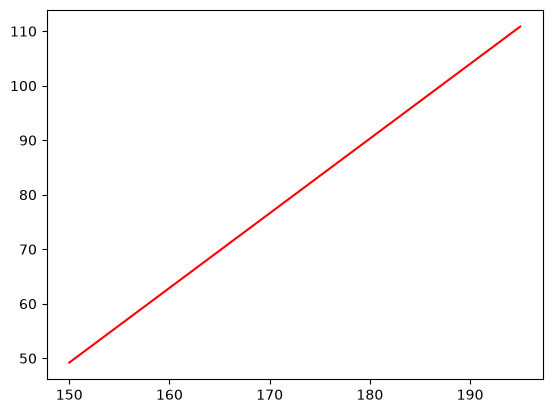

In [62]:
#Observamos como nos quedó la recta
x = np.linspace(df.altura.min(), df.altura.max(), 100) #obtenemos 100 valores eq-espaciados entre el min y max del dataset
y_pred = predictor_peso(x)
plt.plot(x, y_pred, color= "red")plt.show()

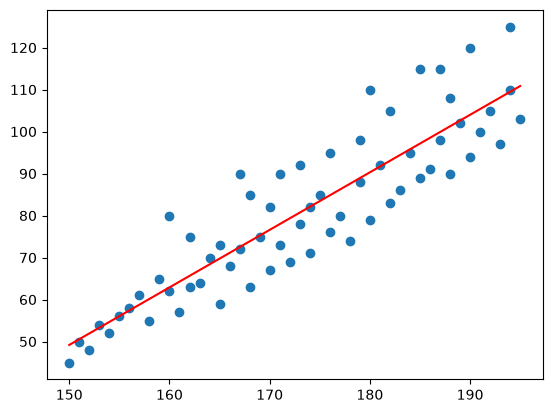

In [63]:
#luego vemos como queda con respecto a los datos:

plt.scatter(df.altura, df.peso)
plt.plot(x, y_pred, color= "red")
plt.show()

In [64]:
#test con mi altura en cm
valor = predictor_peso(169)
print(valor)

75.23049831561451


In [65]:
#Ahora te toca a ti! Prueba con tu altura:

 